In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def LIF(mem, w, x, beta, threshold):
    spk = (mem > threshold)
    spk = spk.astype(float)

    mem = beta*mem + w*x - spk*threshold

    return mem, spk

In [36]:
def ALIF(mem, thr, w, x, beta_mem, beta_thr, thr_base, thr_inc):
    
    spk = (mem > thr)
    spk = spk.astype(float)
    
    mem = beta_mem * mem + w * x - spk * thr
    
    thr = beta_thr * (thr - thr_base) + thr_base + spk * thr_inc
    
    return mem, spk, thr

# Reservoir

## Definition

A reservoir is a fixed, randomly connected recurrent network of neurons. Unlike standard RNNs, the internal weights are not trained — only the output (readout) layer is. The reservoir's role is to project its input into a high-dimensional, nonlinear dynamical state space, such that a simple linear readout can extract whatever structure is needed.

Formally, a reservoir of $N$ neurons is defined by a weight matrix $W_{res} \in \mathbb{R}^{N \times N}$, initialized randomly and then kept frozen throughout training.


In [37]:
num_neurons = 15
connectivity = 0.1


# weight matrix for reservoir. Weights drawn from gaussian with mean 0 and std 0.333s, and with 10% connectivity.
# includes exitatory and inhibitory weights
w_res = np.random.normal(0, 0.333, (num_neurons, num_neurons))

mask = np.random.rand(num_neurons, num_neurons) < connectivity
w_res = w_res * mask
np.fill_diagonal(w_res, 0) # no self-connections

# verify connectivity
actual_connectivity = np.sum(w_res != 0) / (num_neurons * num_neurons)
print(f"Actual connectivity: {actual_connectivity:.2f}")

Actual connectivity: 0.09


## Spectral Radius

The spectral radius $\rho(W_{res})$ is the largest absolute eigenvalue of the reservoir weight matrix. It controls the long-term dynamics of the reservoir.
In practice, $W_{res}$ is first initialized randomly, then rescaled so that its spectral radius matches a chosen target value.


In [38]:
# spectral radius scaling

eigenvalues = np.linalg.eigvals(w_res)
current_sr = np.max(np.abs(eigenvalues))

print("current spectral radius ", current_sr)

# optimal spectral radius
target_sr = 0.9

#TODO more on this
if current_sr > 0: 
    w_res = w_res / current_sr * target_sr

current spectral radius  0.6897720047938367


In [39]:
eigenvalues = np.linalg.eigvals(w_res)
current_sr = np.max(np.abs(eigenvalues))

print("new radius ", current_sr)

new radius  0.8999999999999997


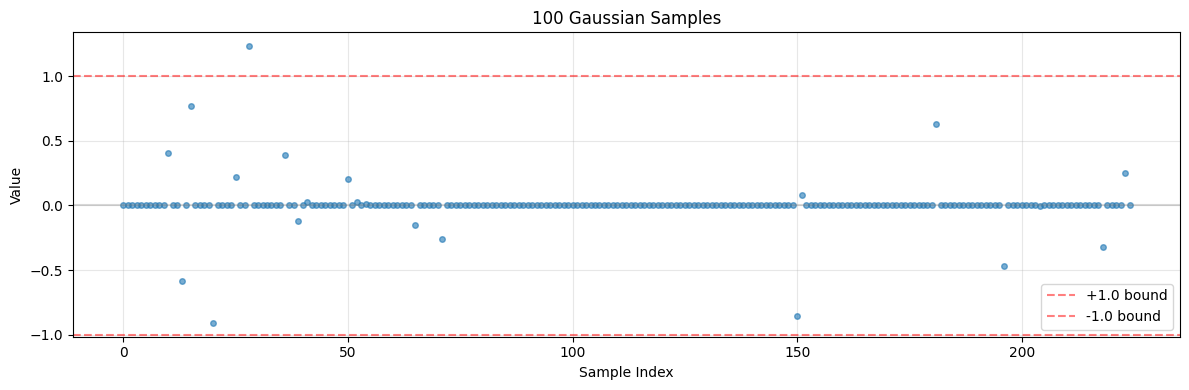

Mean: 0.0025
Std: 0.1535
Min: -0.9079
Max: 1.2309
Within [-0.7, 0.7]: 221 out of 100


In [40]:
samples = w_res.flatten()

plt.figure(figsize=(12, 4))

plt.plot(samples, 'o', alpha=0.6, markersize=4)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='+1.0 bound')
plt.axhline(y=-1.0, color='r', linestyle='--', alpha=0.5, label='-1.0 bound')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('100 Gaussian Samples')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some basic stats
print(f"Mean: {np.mean(samples):.4f}")
print(f"Std: {np.std(samples):.4f}")
print(f"Min: {np.min(samples):.4f}")
print(f"Max: {np.max(samples):.4f}")
print(f"Within [-0.7, 0.7]: {np.sum((samples >= -0.7) & (samples <= 0.7))} out of 100")

In [41]:
num_steps = 150
input_firing_rate = 0.4
input_connectivity = 0.3

# generating input spikes
input_neurons = np.random.choice(num_neurons, size=int(num_neurons * input_connectivity), replace=False)


def gen_spikes(rate_tensor):
    random_vals = np.random.random(rate_tensor.shape)
    spikes = (random_vals < rate_tensor).astype(float)
    return spikes

# only input_neurons have non-zero firing rate
rate_tensor = np.zeros((num_steps, num_neurons)) #(num_steps, num_neurons)
rate_tensor[:, input_neurons] = input_firing_rate  # 40% firing rate for input neurons

input_spikes = gen_spikes(rate_tensor)

print(f"Input spikes shape: {input_spikes.shape}")
print(f"Avg spikes per timestep: {np.sum(input_spikes)/num_steps:.2f}")
print(f"Active neurons in first timeframe: {np.sum(input_spikes[0], axis=0)}/{len(input_neurons)}")


print(f"Input spikes at first timeframe: {input_spikes[0]}")



Input spikes shape: (150, 15)
Avg spikes per timestep: 1.43
Active neurons in first timeframe: 2.0/4
Input spikes at first timeframe: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.]


## LIF Reservoir

The recurrent LIF extends the standard LIF by adding recurrent input from the reservoir's own previous spike state:

$$\text{total\_input}[t] = x[t] + W_{res} \cdot s[t-1]$$

$$m[t+1] = \beta \cdot m[t] + \text{total\_input}[t] - s[t] \cdot \vartheta$$

The reservoir state at each timestep is therefore a function of both the external input and the network's own recent activity, which is what gives it its memory and nonlinear mixing properties.

In [42]:
def LIF_res(prev_mem, prev_spk, w_res, input_spikes, beta, threshold):

    recurrent_input = w_res @ prev_spk  # (num_neurons,)
    
    total_input = input_spikes + recurrent_input # (num_neurons,)

    spk = (prev_mem > threshold).astype(float)
    mem = beta * prev_mem + total_input - spk * threshold
    
    return mem, spk

## Simulation loop

In [43]:
num_neurons = 15
num_steps = 150

delta_t = np.array(1e-3)
tau = np.array(5e-3) 
mem_beta = np.exp(-delta_t/tau) # = 0.8187

threshold = 1.0

# randomize initial membrane potentials
mem = np.random.uniform(0, threshold, size=num_neurons)
spk = np.random.uniform(0, threshold, size=num_neurons)
spk_rec = np.zeros((num_steps, num_neurons)) # to record spikes over time
mem_rec = np.zeros((num_steps, num_neurons)) # to record membrane potentials over time


for t in range(num_steps):

    #TODO use weights or not for input ?
    I = input_spikes[t]

    mem, spk = LIF_res(mem, spk, w_res, I, mem_beta, threshold)
    spk_rec[t] = spk
    mem_rec[t] = mem


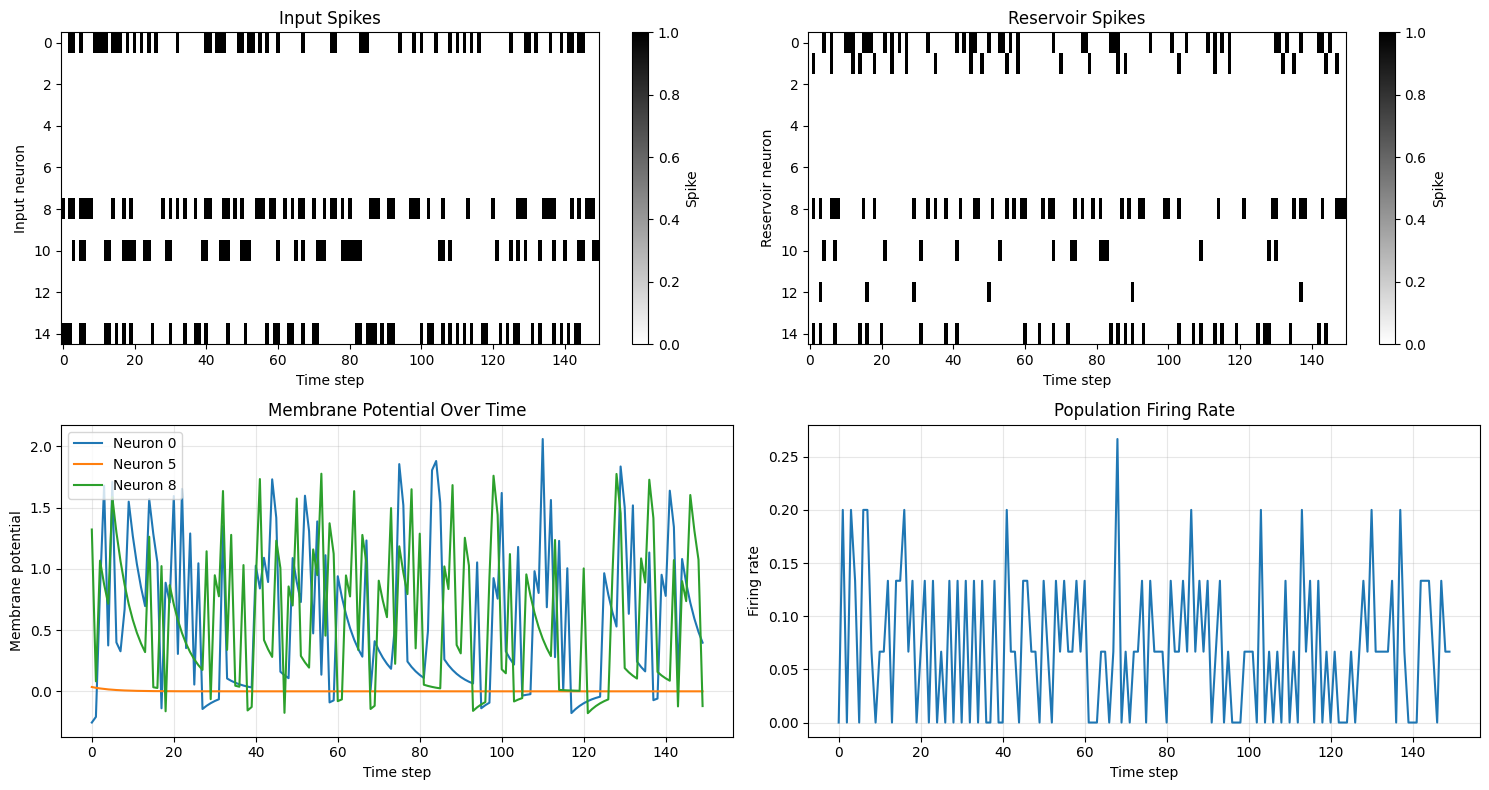

In [45]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(input_spikes[:, :].T, aspect='auto', cmap='binary')
plt.xlabel('Time step')
plt.ylabel('Input neuron')
plt.title('Input Spikes')
plt.colorbar(label='Spike')

plt.subplot(2, 2, 2)
plt.imshow(spk_rec[:, :].T, aspect='auto', cmap='binary')
plt.xlabel('Time step')
plt.ylabel('Reservoir neuron')
plt.title('Reservoir Spikes')
plt.colorbar(label='Spike')

plt.subplot(2, 2, 3)
sample_neurons = [0, 5,8]
for neuron in sample_neurons:
    plt.plot(mem_rec[:, neuron], label=f'Neuron {neuron}')
plt.xlabel('Time step')
plt.ylabel('Membrane potential')
plt.title('Membrane Potential Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
firing_rate = np.sum(spk_rec, axis=1) / num_neurons
plt.plot(firing_rate[:])
plt.xlabel('Time step')
plt.ylabel('Firing rate')
plt.title('Population Firing Rate')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

## Class variation

In [50]:
class Random_reservoir:
    def __init__(self, hyperparameters):
        self.num_neurons = hyperparameters.get("num_neurons")
        self.input_connectivity = hyperparameters.get("input_connectivity")
        self.num_steps = hyperparameters.get("num_steps")
        self.input_firing_rate = hyperparameters.get("input_firing_rate")
        self.weight_connectivity = hyperparameters.get("weight_connectivity")
        self.LIF_beta = hyperparameters.get("LIF_beta")
        self.LIF_threshold = hyperparameters.get("LIF_threshold")
        

    def init_weights(self):

        # weight matrix for reservoir. Weights drawn from gaussian with mean 0 and std 0.333s, and with 10% connectivity.
        # includes exitatory and inhibitory weights.
        w_res = np.random.normal(0, 0.333, (self.num_neurons, self.num_neurons))

        mask = np.random.rand(self.num_neurons, self.num_neurons) < self.weight_connectivity
        w_res = w_res * mask
        np.fill_diagonal(w_res, 0) # no self-connections

        return w_res
        

    def init_inputs(self):
        input_neurons = np.random.choice(self.num_neurons, size=int(self.num_neurons * self.input_connectivity), replace=False)

        # only input_neurons have non-zero firing rate
        rate_tensor = np.zeros((self.num_steps, self.num_neurons)) #(num_steps, num_neurons)
        rate_tensor[:, input_neurons] = self.input_firing_rate  # 40% firing rate for input neurons

        input_tensor = self.gen_spikes(rate_tensor)
        return input_tensor

    def gen_spikes(self, rate_tensor):
        random_vals = np.random.random(rate_tensor.shape)
        spikes = (random_vals < rate_tensor).astype(float)
        return spikes
    

    def simulate(self, w_res, input_tensor):

        mem = np.zeros(self.num_neurons)
        spk = np.zeros(self.num_neurons)
        spk_rec = np.zeros((self.num_steps, self.num_neurons))
        mem_rec = np.zeros((self.num_steps, self.num_neurons))
        


        for t in range(self.num_steps):

            I = input_tensor[t]

            mem, spk = self.LIF_res(mem, spk, w_res, I, self.LIF_beta, self.LIF_threshold)
            spk_rec[t] = spk
            mem_rec[t] = mem

        return mem_rec, spk_rec

    def LIF_res(self, prev_mem, prev_spk, w_res, input_spikes, beta, threshold):

        recurrent_input = w_res @ prev_spk  # (num_neurons,)
        
        total_input = input_spikes + recurrent_input # (num_neurons,)

        spk = (prev_mem > threshold).astype(float)
        mem = beta * prev_mem + total_input - spk * threshold
        
        return mem, spk
    
    def visualize_results(self, input_tensor, mem_rec, spk_rec):
        
        plt.figure(figsize=(15, 10))

        # sample neuron membrane potential
        plt.subplot(3, 2, 1)
        sample_neurons = [0, 5,8]
        for neuron in sample_neurons:
            plt.plot(mem_rec[:, neuron], label=f'Neuron {neuron}')
        plt.xlabel('Time step')
        plt.ylabel('Membrane potential')
        plt.title('Membrane Potential Over Time')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # population firing rate
        plt.subplot(3, 2, 2)
        firing_rate = np.sum(spk_rec, axis=1) / self.num_neurons
        plt.plot(firing_rate[:])
        plt.xlabel('Time step')
        plt.ylabel('Firing rate')
        plt.title('Population Firing Rate')
        plt.grid(True, alpha=0.3)

        # weight matrix
        plt.subplot(3, 2, 3)
        plt.imshow(w_res[:, :], cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
        plt.xlabel('Target neuron')
        plt.ylabel('Source neuron')
        plt.title('Reservoir Weights')
        plt.colorbar(label='Weight')

        # input spikes
        plt.subplot(3, 2, 5)
        plt.imshow(input_tensor[:, :].T, aspect='auto', cmap='binary')
        plt.xlabel('Time step')
        plt.ylabel('Input neuron')
        plt.title('Input Spikes')
        plt.colorbar(label='Spike')

        # reservoir spikes
        plt.subplot(3, 2, 6)
        plt.imshow(spk_rec[:, :].T, aspect='auto', cmap='binary')
        plt.xlabel('Time step')
        plt.ylabel('Reservoir neuron')
        plt.title('Reservoir Spikes')
        plt.colorbar(label='Spike')

        plt.tight_layout()
        plt.show()

        spikes_per_neuron = np.sum(spk_rec, axis=0)  # total spikes for each neuron over all timesteps
        silent_neurons = np.sum(spikes_per_neuron == 0)  # count of neurons with zero spikes
        silent_percentage = (silent_neurons / hp["num_neurons"]) * 100

        mem_changes = np.any(np.diff(mem_rec, axis=0) != 0, axis=0)  # True if membrane ever changed
        isolated_neurons = np.sum(~mem_changes)  # count of neurons with no membrane changes
        isolated_percentage = (isolated_neurons / hp["num_neurons"]) * 100

        # Print results
        print(f"Silent/Dead neurons (never spiked): {silent_neurons}/{hp['num_neurons']} ({silent_percentage:.1f}%)")
        #TODO calculate this differently, maybe from w_res, as membrane will always change (decay)
        print(f"Isolated neurons (membrane never changed): {isolated_neurons}/{hp['num_neurons']} ({isolated_percentage:.1f}%)")



hp = {
    "num_steps": 1000,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.8187,
    "LIF_threshold": 1.0,
}

rand_res = Random_reservoir(hp)
input_tensor = rand_res.init_inputs()
w_res = rand_res.init_weights()
mem_rec, spk_rec = rand_res.simulate(w_res, input_tensor)


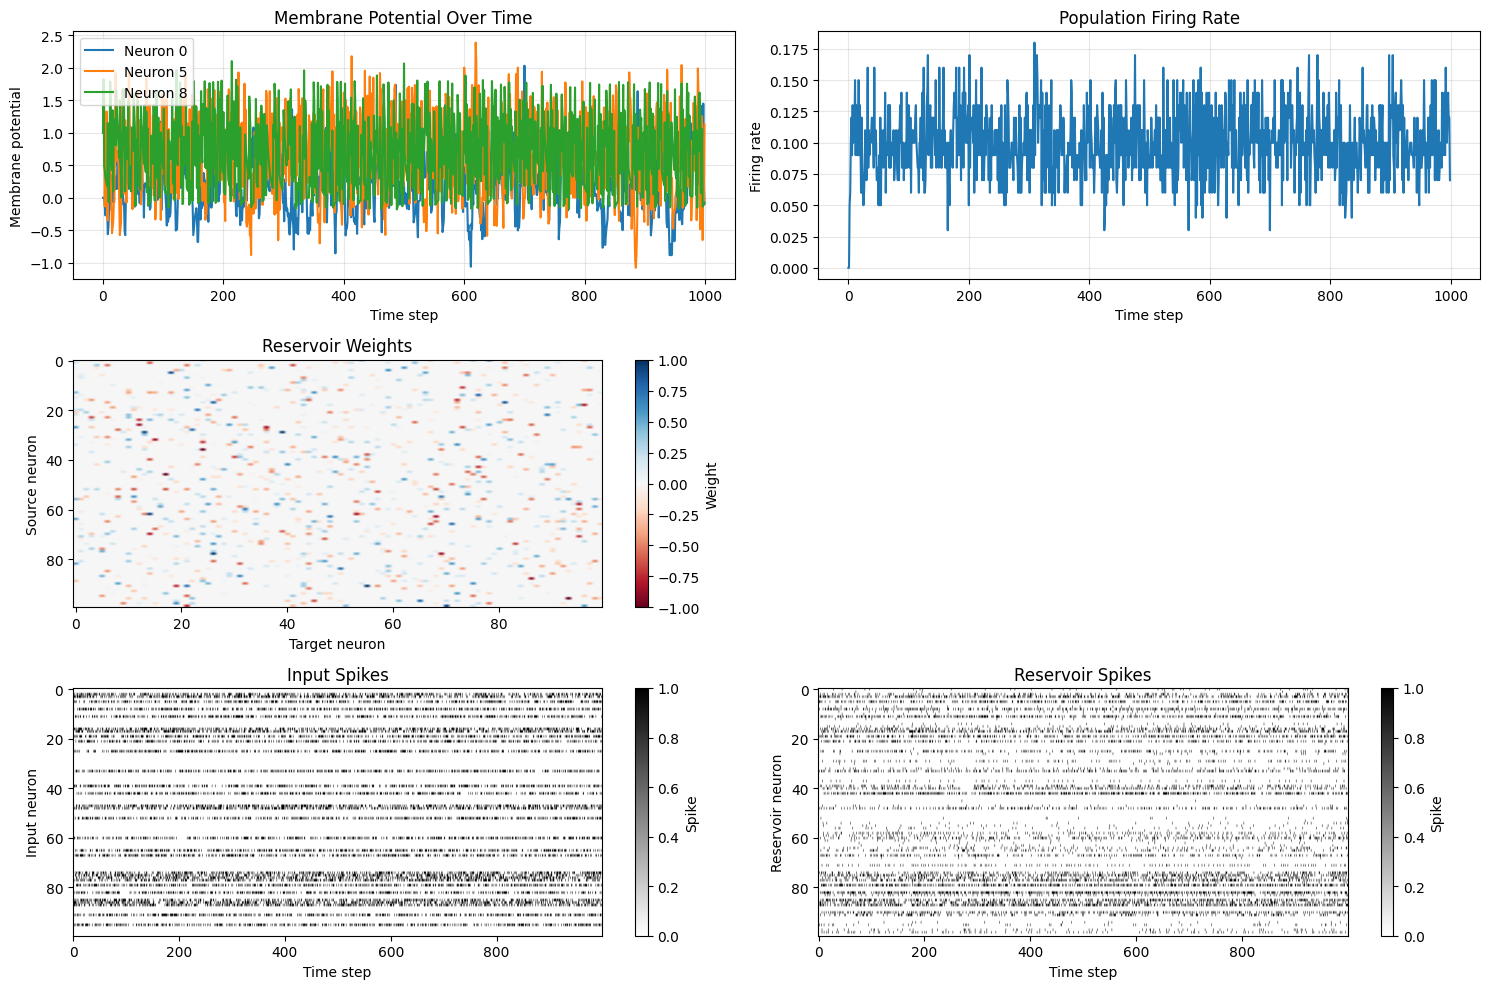

Silent/Dead neurons (never spiked): 32/100 (32.0%)
Isolated neurons (membrane never changed): 0/100 (0.0%)


In [51]:
rand_res.visualize_results(input_tensor, mem_rec, spk_rec)